In [7]:
!pip install -q -U transformers torch

In [8]:
import pandas as pd
import torch
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [9]:
from google.colab import files
uploaded = files.upload()

Saving DEV_TEST_Merged_ASQE_N2500.jsonl to DEV_TEST_Merged_ASQE_N2500 (1).jsonl
Saving Train_validation_Merged_ASQE_N4000.jsonl to Train_validation_Merged_ASQE_N4000 (1).jsonl


In [15]:
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

train_df = load_jsonl("Train_validation_Merged_ASQE_N4000.jsonl")
test_df = load_jsonl("DEV_TEST_Merged_ASQE_N2500.jsonl")

print(train_df.columns)
train_df.head()

Index(['text', 'labels'], dtype='object')


,text,labels
0,He is not helpful at all and makes fun of stud...,"[{'aspect': 'He', 'opinion': 'Very rude', 'pol..."
1,"This course was amazing. For the first time, t...","[{'aspect': 'This course', 'opinion': 'I loved..."
2,Exams were very easy and he allowed us to do e...,"[{'aspect': 'Exams', 'opinion': 'very easy', '..."
3,The lecturers from Exeter have helped me throu...,"[{'aspect': 'lecturers', 'opinion': 'helped me..."
4,"Extremely boring and lectures were useless, bu...","[{'aspect': 'lectures', 'opinion': 'Extremely ..."


In [16]:
def convert_to_absa(df):
    rows = []

    for _, row in df.iterrows():
        text = str(row.get("text", "")).strip()
        labels = row.get("labels", [])

        if not isinstance(labels, list):
            continue

        seen = set()

        for item in labels:
            aspect = str(item.get("aspect", "")).strip()
            sentiment = str(item.get("polarity", "")).strip().lower()

            # Skip invalid entries
            if not text or not aspect or not sentiment:
                continue

            key = (text, aspect, sentiment)

            if key not in seen:
                rows.append({
                    "sentence": text,
                    "aspect": aspect,
                    "sentiment": sentiment
                })
                seen.add(key)

    return pd.DataFrame(rows)

In [32]:
train_absa = convert_to_absa(train_df)
test_absa = convert_to_absa(test_df)

train_absa["sentiment"] = train_absa["sentiment"].str.capitalize()
test_absa["sentiment"] = test_absa["sentiment"].str.capitalize()

In [33]:
print("Train size:", train_absa.shape)
print("Test size:", test_absa.shape)

Train size: (11459, 3)
Test size: (7287, 3)


In [34]:
train_absa["sentiment"].value_counts()

,count
sentiment,
Positive,6120
Negative,3784
Neutral,1555


In [35]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [37]:
label_map = ["Negative", "Neutral", "Positive"]

def predict_absa(sentence, aspect):
    text = f"aspect: {aspect} sentence: {sentence}"

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return label_map[pred]

In [38]:
predictions = []

for i, row in test_absa.iterrows():
    pred = predict_absa(row["sentence"], row["aspect"])
    predictions.append(pred)

    if i % 500 == 0:
        print(f"Processed {i} rows")

test_absa["bertweet_pred"] = predictions

Processed 0 rows
Processed 500 rows
Processed 1000 rows
Processed 1500 rows
Processed 2000 rows
Processed 2500 rows
Processed 3000 rows
Processed 3500 rows
Processed 4000 rows
Processed 4500 rows
Processed 5000 rows
Processed 5500 rows
Processed 6000 rows
Processed 6500 rows
Processed 7000 rows


In [39]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(
    test_absa["sentiment"],
    test_absa["bertweet_pred"]
)

f1 = f1_score(
    test_absa["sentiment"],
    test_absa["bertweet_pred"],
    average="weighted"
)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.6628242074927954
F1 Score: 0.6520493492747611


In [40]:
print(classification_report(
    test_absa["sentiment"],
    test_absa["bertweet_pred"]
))

              precision    recall  f1-score   support

    Negative       0.73      0.58      0.65      2480
     Neutral       0.23      0.19      0.21       970
    Positive       0.71      0.83      0.77      3837

    accuracy                           0.66      7287
   macro avg       0.56      0.54      0.54      7287
weighted avg       0.65      0.66      0.65      7287



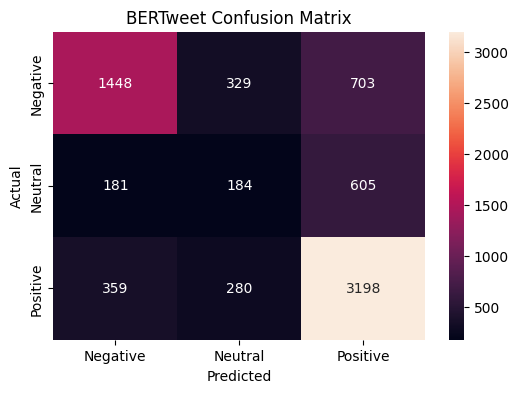

In [41]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(
    test_absa["sentiment"],
    test_absa["bertweet_pred"],
    labels=labels
)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)

plt.title("BERTweet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()